### In this notebook the pipelines need to be built again, and then using class weights and Transfer Learning(an already trained model), the neural network(brain) of this project will be made. 

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os 

In [2]:
dataset_dir = "../Data/PlantVillage"
Image_size = (224,224)
Batch_size = 32
Channels = 3
autotune = tf.data.AUTOTUNE

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2,
    subset = 'training',
    seed = 123,
    image_size = Image_size,
    batch_size = Batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,
    image_size = Image_size,
    batch_size = Batch_size
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


2026-04-17 13:29:09.645841: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-17 13:29:09.645868: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-17 13:29:09.645872: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-17 13:29:09.645914: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-17 13:29:09.645932: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [4]:
class_names = train_ds.class_names
num_classes = len(class_names)

class_weights = {
    0: 1.38, 1: 0.93, 2: 1.38, 3: 1.38, 4: 9.05, 5: 0.65,  #calculated in data exploration notebook
    6: 1.38, 7: 0.72, 8: 1.45, 9: 0.78, 10: 0.82, 
    11: 0.98, 12: 0.43, 13: 3.69, 14: 0.86
}
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2)
])

train_ds = train_ds.cache().shuffle(1000).map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=autotune)
val_ds = val_ds.cache().prefetch(buffer_size=autotune)

### Now is the time to load the pretrained model.
Choosing the right "brain" for a computer vision project is about finding the sweet spot between three conflicting goals: Speed (Latency), Size (Memory), and Brainpower (Accuracy).

#### Why EfficientNetB0?
In the past, researchers scaled models by just making them deeper (adding more layers, like ResNet) or wider (adding more neurons per layer). However, in 2019, Google researchers discovered Compound Scaling. They found that to get the best performance, you shouldn't just scale one dimension; you should scale depth, width, and image resolution together using a fixed set of coefficients.

EfficientNetB0 is the base version of this discovery. It is "Efficient" because:

1. Parameter Efficiency: It achieves better accuracy than models like ResNet-50 while being 4x smaller and 10x faster.

2. Mobile-Ready: Because it's lightweight, it can actually run in real-time on a smartphone—perfect for a "Plant Pathology Assistant" used in a field.

3. Transfer Learning King: It was trained on ImageNet (1.4 million images), meaning it already understands the "texture" of leaves, the "edges" of spots, and the "color" of rot.

---

Google trained EfficientNet on millions of images. Its "brain" outputs complex, 3D mathematical feature maps representing edges, textures, and shapes. But our final goal is just a simple list of 15 probabilities (one for each plant class).

We attached three specific layers to bridge that gap:

1. GlobalAveragePooling2D 
EfficientNet outputs a massive 3D grid of numbers. If that is fed directly into the final layer, the math becomes too heavy, and the model slows to a crawl. Global Average Pooling takes that massive grid and calculates the average of each feature map, compressing a 3D block of data into a flat, lightweight 1D list. It throws away the noise and keeps the core of the image.

2. Dropout(0.2)
If Neural networks can get away with memorizing the exact pixels of the training data instead of actually learning what a disease looks like, they will and cause overfitting.
Every time the model looks at an image during training, Dropout randomly turns off (blinds) 20% of the neurons. The model is forced to learn robust, general features because it can't rely on the same specific neurons every time.

3. Dense(num_classes, activation='softmax')
This is the final output. It calculates the final score for all 15 classes. The softmax activation ensures that all 15 scores are converted into percentages that add up perfectly to 100%.

##### Callbacks
Callbacks are automated "managers" that watch the model while it trains and intervene if things go wrong.

We are going to use the Holy Trinity of Callbacks:

1. EarlyStopping: If the model's accuracy on the Validation set stops improving, it halts training early to save GPU time and prevent overfitting.

2. ModelCheckpoint: It constantly saves the best version of the model to your hard drive, so if your Colab crashes on Epoch 49, you don't lose your work.


3. ReduceLROnPlateau: Imagine running toward a target. You sprint at first, but as you get closer, you slow down to a tip-toe so you don't overshoot it. This callback automatically lowers the "Learning Rate" (speed) as the model gets closer to maximum accuracy.

In [6]:
# Loading EfficientNetB0 without its original head
base_model = tf.keras.applications.EfficientNetB0(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224,224,3)
)

#freezing the pretrained weights
base_model.trainable = False

# building the new head
inputs = tf.keras.Input(shape = (224,224,3))
x = base_model(inputs, training='False')
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation = 'softmax')(x)

model = tf.keras.Model(inputs, outputs)


model = sequential ([ ])
The Sequential API is easy to read, but it assumes the model is a simple, straight line.
x = ... (x)
The Functional API (what we are using) helps to build models with multiple inputs, branching paths, and multiple outputs. To do this, python needs to be explicitly told where data is flowing. 

1. inputs = tf.keras.Input(...) → The raw leaf enters the factory.
2. x = base_model(inputs) → The raw leaf goes through the EfficientNet brain. The output is saved as x.
3. x = GlobalAveragePooling2D()(x) → We take the current x, push it through the Pooling layer, and overwrite the variable x with the new result.
4. x = Dropout(0.2)(x) → We take the new x, push it through the Dropout layer, and overwrite x again.

In [7]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
#making models directory if not there
os.makedirs("../models", exist_ok=True)

In [9]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("../models/plant_model_best.keras", save_best_only = True, monitor = 'val_accuracy'),
    tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 3)
]

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    class_weight = class_weights,
    callbacks = callbacks
)

Epoch 1/30


2026-04-17 13:29:11.629969: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-17 13:29:26.379917: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:15: Filling up shuffle buffer (this may take a while): 244 of 1000
2026-04-17 13:29:33.852509: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


516/516 ━━━━━━━━━━━━━━━━━━━━ 250s 435ms/step - accuracy: 0.7319 - loss: 1.0040 - val_accuracy: 0.8515 - val_loss: 0.5702 - learning_rate: 0.0010
Epoch 2/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 272s 525ms/step - accuracy: 0.8643 - loss: 0.4853 - val_accuracy: 0.8873 - val_loss: 0.4242 - learning_rate: 0.0010
Epoch 3/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 195s 377ms/step - accuracy: 0.8889 - loss: 0.3775 - val_accuracy: 0.8963 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 4/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 239s 461ms/step - accuracy: 0.8984 - loss: 0.3270 - val_accuracy: 0.9007 - val_loss: 0.3215 - learning_rate: 0.0010
Epoch 5/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 204s 390ms/step - accuracy: 0.9052 - loss: 0.2986 - val_accuracy: 0.8990 - val_loss: 0.3132 - learning_rate: 0.0010
Epoch 6/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 223s 428ms/step - accuracy: 0.9122 - loss: 0.2760 - val_accuracy: 0.9159 - val_loss: 0.2826 - learning_rate: 0.0010
Epoch 7/30
516/516 ━━━━━━━━━━━━━━━━━━━━ 219s 420ms/step - accuracy: 0.9143 

The Story of Epoch 23

While writing callbacks, EarlyStopping manager had a strict rule: patience=5.
So, somewhere around Epoch 18 (give or take), the model achieved its absolute best score on the validation.

During Epochs 19, 20, 21, 22, and 23, the model kept studying the training data, but its score on the Validation test didn't get any better. In fact, it might have started getting slightly worse (which means it was starting to "Overfit" and memorize the training leaves instead of learning general rules).

At Epoch 23, exactly 5 epochs after the last high score, the manager stepped in and conveyed that further training is wasting time and resource. It killed the training to protect the model.

The moment training stopped, TensorFlow automatically time-traveled and loaded the brain from the absolute best epoch back into memory. The model is in perfectly optimized state. 

In [10]:
#mathematical proofs of model with training behaviour
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_run = range(1, len(acc) + 1)

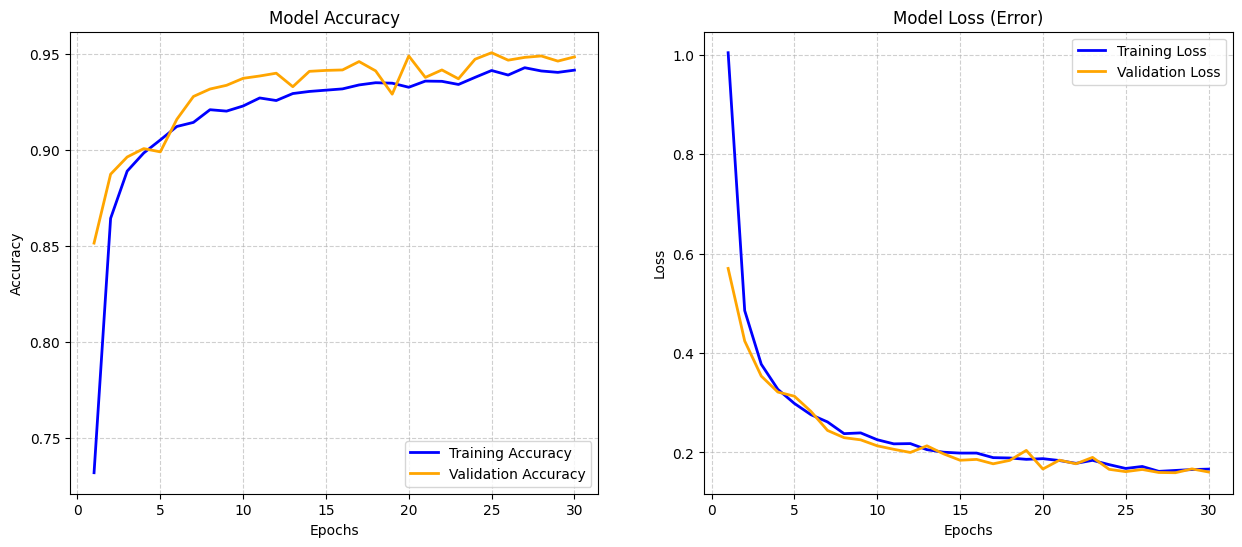

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15,6))

#plot accuracy
ax1.plot(epochs_run, acc, label = 'Training Accuracy', color = 'blue', linewidth = 2)
ax1.plot(epochs_run, val_acc, label = 'Validation Accuracy', color = 'orange', linewidth = 2)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

#plot loss (The  metric earlystopping was watching)
ax2.plot(epochs_run, loss, label = 'Training Loss', color = 'blue', linewidth = 2)
ax2.plot(epochs_run, val_loss, label = 'Validation Loss', color = 'orange', linewidth = 2)
ax2.set_title('Model Loss (Error)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha = 0.6)

plt.show()

#### 

#### It's visible in the second graph the orange line, Validation drops down to the minimum value at 15th epoch and starts plateauing further. This is the maximum performance point of the model.